# Análisis de Embeddings de GNN para Detección de Módulos Funcionales

### Normalización

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuración de rutas ---
data_dir = os.path.join("..", "output")
input_original_file = os.path.join(data_dir, "Trial_2", "embeddings.csv")

print(f"Cargando embeddings ORIGINALES desde: {input_original_file}")
df_original = pd.read_csv(input_original_file)
display(df_original.head())

# --- Extracción de IDs y embeddings ---
protein_ids = df_original.iloc[:, 0]
embedding_columns = df_original.columns[1:]
embeddings_original = df_original[embedding_columns].values

print(f"\nForma de embeddings: {embeddings_original.shape}")
print(f"Tipo de datos: {embeddings_original.dtype}")



Cargando embeddings ORIGINALES desde: ..\output\Trial_2\embeddings.csv


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,54,55,56,57,58,59,60,61,62,63
0,DRD4,-0.142313,-0.141278,0.494164,0.846646,0.836097,0.283319,0.423762,-5.294992,-0.252024,...,2.882641,3.406924,-1.121571,6.407595,-4.043632,-1.190952,2.507818,-2.932565,-5.323580,-2.459242
1,GNB3,-0.415117,-0.242507,0.406739,0.223392,0.582075,0.188306,0.196284,-4.150532,-0.353979,...,1.889544,3.207565,-0.681278,5.950746,-2.966379,-1.540078,2.156890,-1.894218,-5.109250,-2.315631
2,GNB4,-0.597500,0.030235,0.100219,0.190591,0.595881,-0.109062,2.198524,-4.075516,0.380856,...,2.308781,4.115907,-0.109288,5.660621,-2.854630,-1.164790,2.142501,-1.557236,-4.359627,-2.902069
3,AKR1D1,0.909472,-2.640150,0.005248,2.925101,-0.672775,-0.081098,-5.752461,-2.153357,-1.869721,...,-0.918636,1.000845,-1.219806,3.848357,-1.439291,-1.855694,2.642079,0.323994,-5.580482,1.388419
4,CYP2C9,0.590071,-3.341024,0.028180,2.292739,-0.670794,0.483599,-4.017433,-2.176184,-0.837461,...,-0.467530,1.131917,-0.815419,4.270077,-2.090518,-1.792473,2.850012,0.066462,-5.902771,2.312827



Forma de embeddings: (5390, 64)
Tipo de datos: float64


In [71]:
# --- Revisión de calidad ---
print("\n--- Verificación de calidad de los embeddings ---")
num_nan = np.isnan(embeddings_original).any(axis=1).sum()
num_inf = np.isinf(embeddings_original).any(axis=1).sum()
num_zeros = np.all(embeddings_original == 0, axis=1).sum()

print(f"Número de filas con NaN: {num_nan}")
print(f"Número de filas con Inf: {num_inf}")
print(f"Número de vectores de ceros: {num_zeros}")

# Normas L2 antes de normalización
l2_norms_original = np.linalg.norm(embeddings_original, axis=1)
print(f"Mínima norma L2: {np.min(l2_norms_original):.5f}")
print(f"Máxima norma L2: {np.max(l2_norms_original):.5f}")
print(f"Promedio norma L2: {np.mean(l2_norms_original):.5f}")



--- Verificación de calidad de los embeddings ---
Número de filas con NaN: 0
Número de filas con Inf: 0
Número de vectores de ceros: 0
Mínima norma L2: 7.66943
Máxima norma L2: 48.23468
Promedio norma L2: 20.42731


In [78]:
from sklearn.preprocessing import Normalizer

print("\n--- Normalizando embeddings con sklearn Normalizer (L2) ---")

# Creamos el normalizador L2
l2_normalizer = Normalizer(norm='l2')

# Aplicamos la normalización a todos los vectores fila
embeddings_normalized = l2_normalizer.fit_transform(embeddings_original)

# Verificamos normas L2 post-normalización
l2_post = np.linalg.norm(embeddings_normalized, axis=1)

print(f"Norma L2 mínima después: {np.min(l2_post):.10f}")
print(f"Norma L2 máxima después: {np.max(l2_post):.10f}")
print(f"Norma L2 media después: {np.mean(l2_post):.10f}")
print(f"¿Todas las normas son ≈1? {np.allclose(l2_post, 1.0, atol=1e-7)}")

# gaurdar como nuevo CSV
output_dir = os.path.join("..", "output", "Trial_2")
output_file = os.path.join(output_dir, "embeddings_normalizados.csv")

df_normalized = pd.DataFrame(embeddings_normalized, columns=embedding_columns)
df_normalized.insert(0, df_original.columns[0], protein_ids)

print(f"\nGuardando embeddings normalizados en: {output_file}")
df_normalized.to_csv(output_file, index=False)

# Estadísticas descriptivas
print("\n--- Estadísticas de los embeddings normalizados ---")
display(df_normalized[embedding_columns].describe())




--- Normalizando embeddings con sklearn Normalizer (L2) ---
Norma L2 mínima después: 1.0000000000
Norma L2 máxima después: 1.0000000000
Norma L2 media después: 1.0000000000
¿Todas las normas son ≈1? True

Guardando embeddings normalizados en: ..\output\Trial_2\embeddings_normalizados.csv

--- Estadísticas de los embeddings normalizados ---


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
count,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,...,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000,5390.000000
mean,-0.091687,-0.000539,-0.018876,-0.019306,0.035221,-0.044310,-0.014481,-0.015928,-0.003635,0.018275,...,-0.028537,0.072470,0.016006,0.259006,-0.027629,-0.164771,-0.017065,-0.021452,-0.169870,-0.071506
std,0.090909,0.068184,0.053347,0.077662,0.052651,0.059705,0.215843,0.075346,0.098238,0.063227,...,0.081541,0.117164,0.092794,0.060088,0.078872,0.060089,0.073101,0.066587,0.071276,0.106501
min,-0.284864,-0.233736,-0.217727,-0.286204,-0.121030,-0.257598,-0.531270,-0.209550,-0.242056,-0.190433,...,-0.305278,-0.197522,-0.250467,-0.024376,-0.174630,-0.321835,-0.198779,-0.145979,-0.327884,-0.322952
25%,-0.167679,-0.038073,-0.054199,-0.066910,0.009990,-0.079556,-0.167700,-0.060093,-0.065030,-0.024833,...,-0.081245,-0.019260,-0.050269,0.222956,-0.084371,-0.209435,-0.067727,-0.078377,-0.220461,-0.157910
50%,-0.105505,0.010822,-0.010588,-0.011474,0.046089,-0.035605,0.006065,-0.008308,0.001774,0.007102,...,-0.023467,0.088386,0.007621,0.262465,-0.042943,-0.170933,-0.022859,-0.027583,-0.165383,-0.072181
75%,-0.017850,0.044964,0.022067,0.034396,0.070753,-0.002695,0.138825,0.039177,0.073679,0.062209,...,0.026470,0.164898,0.077395,0.301061,0.015817,-0.125369,0.034680,0.026587,-0.125210,0.012624
max,0.149706,0.177751,0.090538,0.212304,0.204461,0.080166,0.466781,0.179140,0.242765,0.199227,...,0.161042,0.313752,0.306947,0.400366,0.245886,0.032700,0.183114,0.182538,0.129212,0.238989


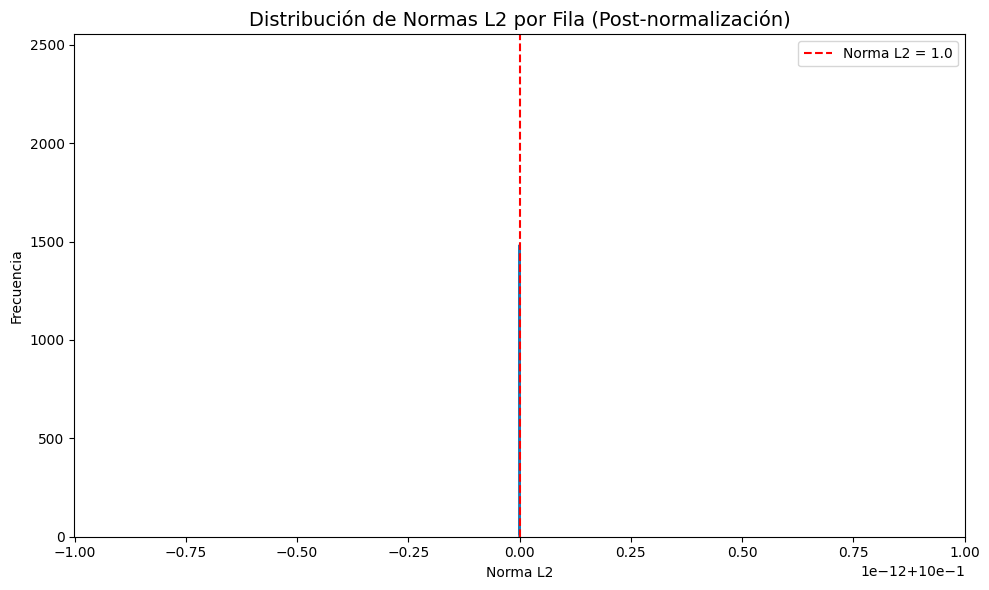

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verifica la norma L2 de cada fila
l2_post = np.linalg.norm(embeddings_normalized, axis=1)

# Histograma
plt.figure(figsize=(10, 6))
sns.histplot(l2_post, bins=30, kde=True, edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='Norma L2 = 1.0')
plt.title("Distribución de Normas L2 por Fila (Post-normalización)", fontsize=14)
plt.xlabel("Norma L2")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


In [80]:
# Revisión programática
np.allclose(l2_post, 1.0, atol=1e-7)


True

In [81]:
# Mostrar primeras 10 normas
pd.Series(l2_post).head(10)


0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
dtype: float64

In [84]:
# Buscar normas que no estén cerca de 1
pd.Series(l2_post)[~np.isclose(l2_post, 1.0, atol=1e-7)]


Series([], dtype: float64)

Todas las filas están normalizadas

In [85]:
import pandas as pd
import numpy as np

# Convertir normas a Series de pandas
l2_series = pd.Series(l2_post)

# Generar resumen por percentiles
summary = l2_series.describe(percentiles=[0.25, 0.5, 0.75])

# Renombrar índice para claridad
summary.index = ['Cantidad', 'Media', 'Desviación estándar', 'Mínimo', '25%', '50%', '75%', 'Máximo']

# Mostrar tabla
print("\n--- Resumen estadístico de normas L2 por fila ---")
display(summary.to_frame(name='Norma L2'))



--- Resumen estadístico de normas L2 por fila ---


,Norma L2
Cantidad,5.390000e+03
Media,1.000000e+00
Desviación estándar,1.499911e-16
Mínimo,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
Máximo,1.000000e+00


Efectivamente todas las filas tienen norma 1

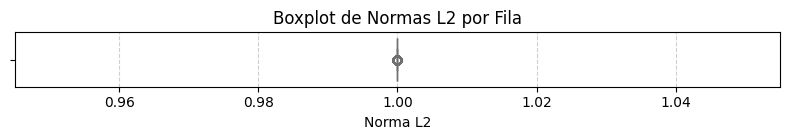

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 1.5))
sns.boxplot(x=l2_post, color='skyblue')
plt.title("Boxplot de Normas L2 por Fila", fontsize=12)
plt.xlabel("Norma L2")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


todas las filas tienen norma exactamente igual a 1.0. 

### Reducción de dimensionalidad

c:\Users\Macarena Madrid\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


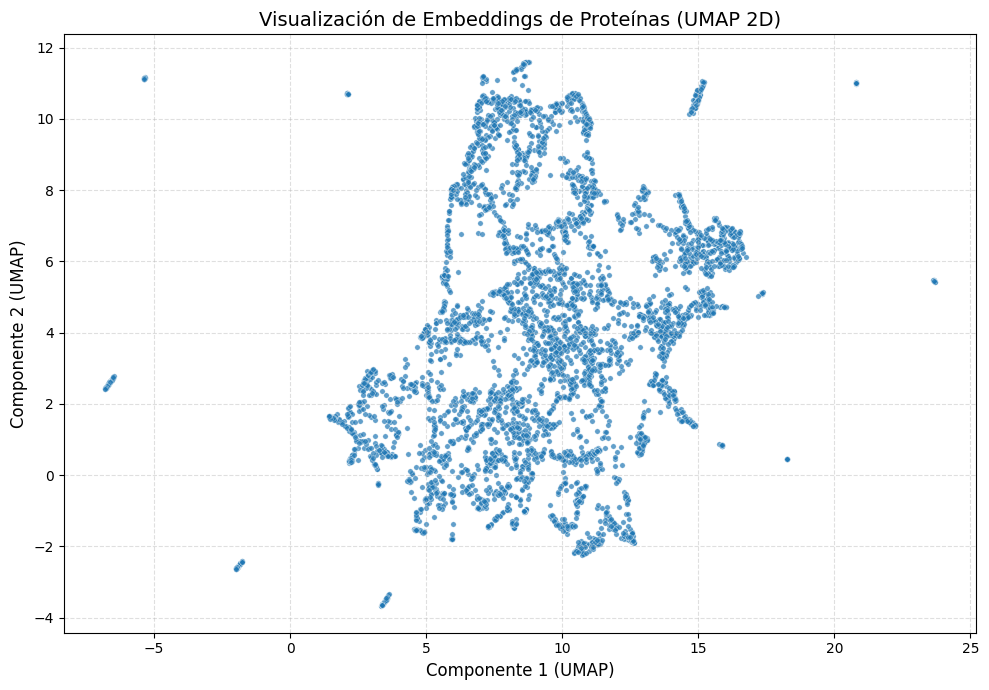

In [89]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# Reducir a 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings_normalized)

# Guardar para clustering futuro
df_2d = pd.DataFrame(embedding_2d, columns=["UMAP_1", "UMAP_2"])
df_2d["Proteina"] = protein_ids.values  # si quieres usarlo luego

# --- Visualización: estructura de los embeddings ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x="UMAP_1", y="UMAP_2", data=df_2d, s=15, alpha=0.7)
plt.title("Visualización de Embeddings de Proteínas (UMAP 2D)", fontsize=14)
plt.xlabel("Componente 1 (UMAP)", fontsize=12)
plt.ylabel("Componente 2 (UMAP)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### UMAP con KMEANS. K=5

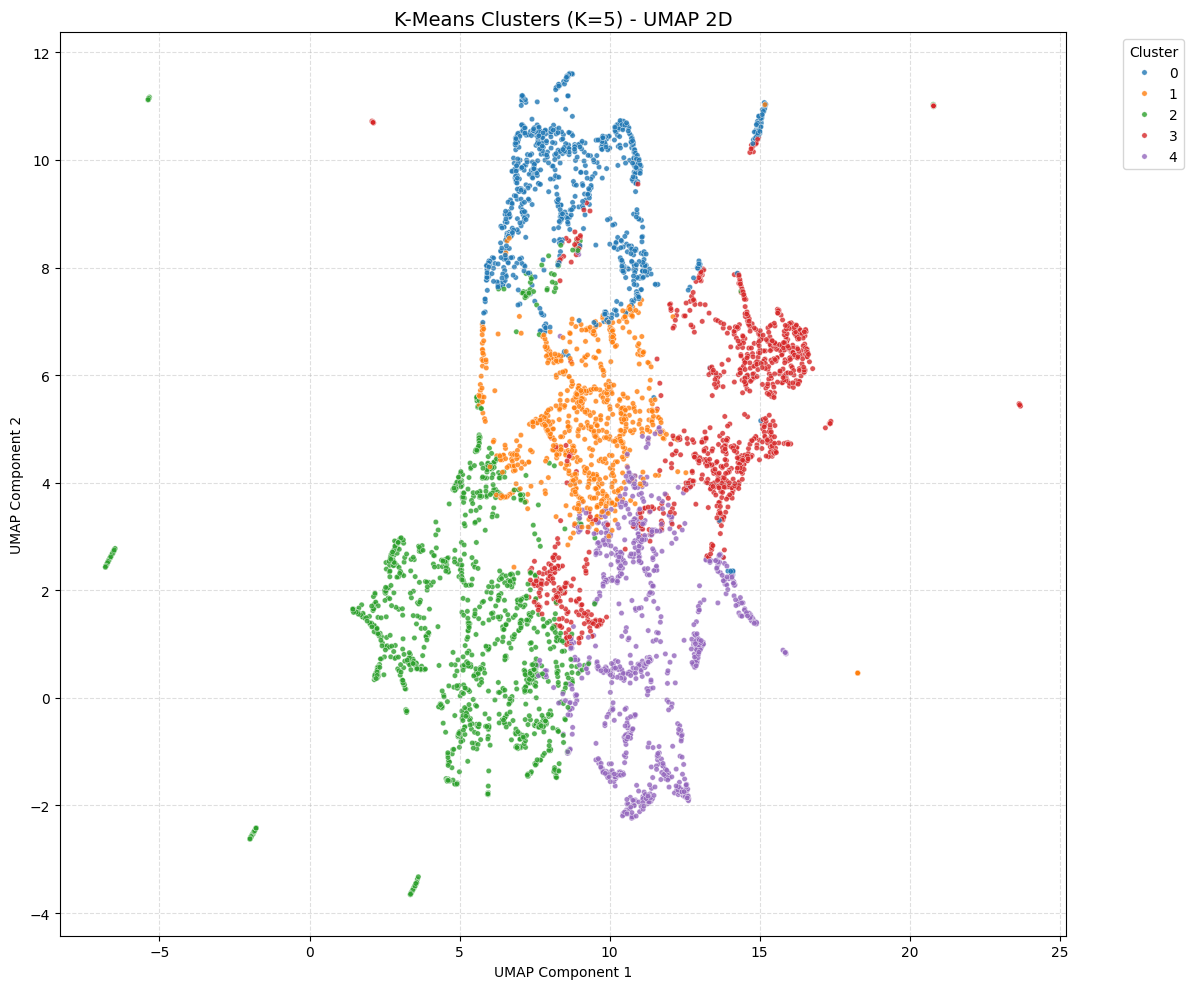

In [98]:

from sklearn.cluster import KMeans
labels = KMeans(n_clusters=5).fit_predict(embeddings_normalized)

# Agrega las etiquetas al DataFrame
df_2d["Cluster"] = labels

# Visualización coloreada por cluster
plt.figure(figsize=(12, 10))
sns.scatterplot(x="UMAP_1", y="UMAP_2", hue="Cluster", data=df_2d, palette="tab10", s=15, alpha=0.8)
plt.title("K-Means Clusters (K=5) - UMAP 2D", fontsize=14)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### UMAP con mejor DBSCAN. eps=0.0064 y min_samples=90

c:\Users\Macarena Madrid\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


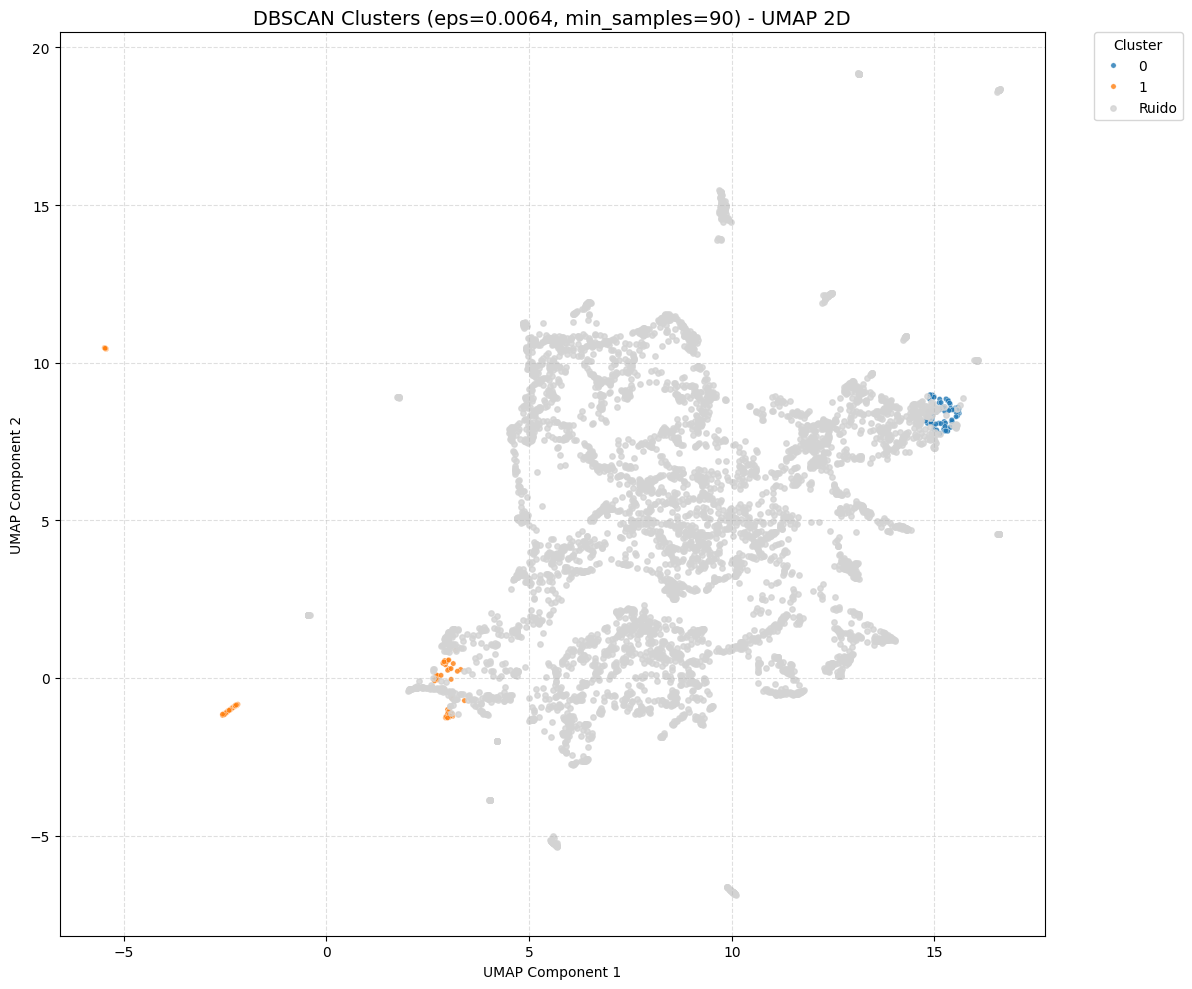

In [100]:
from sklearn.cluster import DBSCAN
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Aplicar DBSCAN ---
dbscan = DBSCAN(eps=0.0064, min_samples=90, metric='cosine')
labels_dbscan = dbscan.fit_predict(embeddings_normalized)

# --- 2. Reducir a 2D con UMAP ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_umap = reducer.fit_transform(embeddings_normalized)

# --- 3. Crear DataFrame ---
df_dbscan = pd.DataFrame({
    "UMAP_1": embeddings_umap[:, 0],
    "UMAP_2": embeddings_umap[:, 1],
    "Cluster": labels_dbscan
})

# --- 4. Visualización: ruido en gris ---
plt.figure(figsize=(12, 10))

# Separar ruido y clusters válidos
df_noise = df_dbscan[df_dbscan["Cluster"] == -1]
df_clusters = df_dbscan[df_dbscan["Cluster"] != -1]

# Paleta de colores para clusters válidos
n_clusters = len(df_clusters["Cluster"].unique())
palette = sns.color_palette("tab10", n_colors=n_clusters)

# Graficar clusters válidos
sns.scatterplot(
    x="UMAP_1", y="UMAP_2",
    hue="Cluster", data=df_clusters,
    palette=palette,
    s=15, alpha=0.8, legend="full"
)

# Graficar puntos de ruido en gris
plt.scatter(
    df_noise["UMAP_1"], df_noise["UMAP_2"],
    c="lightgray", s=15, label="Ruido", alpha=0.8
)

# Títulos y leyenda
plt.title("DBSCAN Clusters (eps=0.0064, min_samples=90) - UMAP 2D", fontsize=14)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# GRÁFICOS PARA ANEXOS

### DBSCAN

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuración de rutas ---
data_dir = os.path.join("..", "output")
file = os.path.join(data_dir, "Trial_2", "clustering_optimization_results", "dbscan_parameter_search_results_extended.csv")
RESULTS_GRAPH_DIR = os.path.join(data_dir, "Trial_2", "clustering_optimization_results", "plots")
os.makedirs(RESULTS_GRAPH_DIR, exist_ok=True)

print(f"Cargando datos desde: {file}")
df_dbscan_results = pd.read_csv(file)

# Mostrar las primeras filas
display(df_dbscan_results.head())

# Mostrar nombres de las columnas
print("\n--- Columnas del DataFrame ---")
print(df_dbscan_results.columns.tolist())

Cargando datos desde: ..\output\Trial_2\clustering_optimization_results\dbscan_parameter_search_results_extended.csv


,eps,min_samples,Num Clusters (valid),Num Ruido,Porcentaje Ruido,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,0.0064,90,2,5116,94.916512,0.900595,0.146454,10792.874926
1,0.0064,80,2,5101,94.638219,0.896576,0.153028,10877.483661
2,0.0064,70,2,5096,94.545455,0.895209,0.155033,10853.326171
3,0.0064,60,2,5085,94.341373,0.891667,0.160021,10610.429867
4,0.0010,30,4,5211,96.679035,0.882492,0.152789,11710.615632



--- Columnas del DataFrame ---
['eps', 'min_samples', 'Num Clusters (valid)', 'Num Ruido', 'Porcentaje Ruido', 'Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index']


In [106]:
# Filtrar combinaciones con al menos 2 clusters válidos
plot_df_dbscan = df_dbscan_results[df_dbscan_results['Num Clusters (valid)'] >= 2].copy()

if plot_df_dbscan.empty:
    print("⚠️ Advertencia: No hay suficientes combinaciones de parámetros con al menos 2 clusters válidos.")
else:
    # --- Generación de Heatmaps para DBSCAN ---
    print("\n🗺️ Generando heatmaps para DBSCAN...")

    metrics_to_plot = {
        'Silhouette Score': {
            'title': 'DBSCAN: Silhouette Score',
            'cmap': 'viridis', 'fmt': ".2f", 'is_higher_better': True
        },
        'Davies-Bouldin Index': {
            'title': 'DBSCAN: Davies-Bouldin Index',
            'cmap': 'plasma_r', 'fmt': ".2f", 'is_higher_better': False
        },
        'Calinski-Harabasz Index': {
            'title': 'DBSCAN: Calinski-Harabasz Index',
            'cmap': 'magma', 'fmt': ".0f", 'is_higher_better': True
        },
        'Porcentaje Ruido': {
            'title': 'DBSCAN: Porcentaje de Ruido',
            'cmap': 'Reds_r', 'fmt': ".1f", 'is_higher_better': False
        },
        'Num Clusters (valid)': {
            'title': 'DBSCAN: Número de Clústeres Válidos',
            'cmap': 'Blues', 'fmt': ".0f", 'is_higher_better': True
        }
    }

    for metric_name, params in metrics_to_plot.items():
        pivot_table = plot_df_dbscan.pivot_table(
            index='min_samples',
            columns='eps',
            values=metric_name
        )

        plt.figure(figsize=(14, 10))
        sns.heatmap(
            pivot_table,
            annot=True,
            cmap=params['cmap'],
            fmt=params['fmt'],
            linewidths=.5,
            linecolor='lightgray'
        )

        plt.title(params['title'] + ' por (eps, min_samples)', fontsize=16)
        plt.xlabel('Eps', fontsize=12)
        plt.ylabel('Min Samples', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        # Guardar figura
        file_name = f"dbscan_{metric_name.lower().replace(' ', '_').replace('(valid)', '').replace('(', '').replace(')', '')}_heatmap.png"
        full_path = os.path.join(RESULTS_GRAPH_DIR, file_name)
        plt.savefig(full_path, dpi=300)
        plt.close()

        print(f"✅ Heatmap de '{metric_name}' guardado en: {full_path}")

print("\n✅ Visualización de DBSCAN completada.")


🗺️ Generando heatmaps para DBSCAN...
✅ Heatmap de 'Silhouette Score' guardado en: ..\output\Trial_2\clustering_optimization_results\plots\dbscan_silhouette_score_heatmap.png
✅ Heatmap de 'Davies-Bouldin Index' guardado en: ..\output\Trial_2\clustering_optimization_results\plots\dbscan_davies-bouldin_index_heatmap.png
✅ Heatmap de 'Calinski-Harabasz Index' guardado en: ..\output\Trial_2\clustering_optimization_results\plots\dbscan_calinski-harabasz_index_heatmap.png
✅ Heatmap de 'Porcentaje Ruido' guardado en: ..\output\Trial_2\clustering_optimization_results\plots\dbscan_porcentaje_ruido_heatmap.png
✅ Heatmap de 'Num Clusters (valid)' guardado en: ..\output\Trial_2\clustering_optimization_results\plots\dbscan_num_clusters__heatmap.png

✅ Visualización de DBSCAN completada.


### HDBSCAN

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuración de rutas ---
data_dir = os.path.join("..", "output")
file = os.path.join(data_dir, "Trial_2", "clustering_optimization_results", "hdbscan_parameter_search_results_exhaustive.csv")
RESULTS_GRAPH_DIR = os.path.join(data_dir, "Trial_2", "clustering_optimization_results", "plots")
os.makedirs(RESULTS_GRAPH_DIR, exist_ok=True)

# --- Cargar datos ---
print(f"Cargando datos desde: {file}")
df_hdb = pd.read_csv(file)

Cargando datos desde: ..\output\Trial_2\clustering_optimization_results\hdbscan_parameter_search_results_exhaustive.csv


In [124]:
# --- Filtro por cse=0.0 y alpha=1.5 ---
df_hdb = df_hdb[
    (df_hdb["cluster_selection_epsilon"] == 0.0) &
    (df_hdb["alpha"] == 2.0) &
    (df_hdb["Num Clusters (valid)"] >= 2)
].copy()

if df_hdb.empty:
    print("⚠️ No hay combinaciones con cse=0.0, alpha=2.0 y al menos 2 clusters válidos.")
else:
    print("\n✅ Generando heatmaps para combinaciones con cse=0.0 y alpha=2.0...\n")

    metrics_to_plot = {
        'Silhouette Score': {
            'title': 'HDBSCAN: Silhouette Score (cse=0.00, alpha=2.0)',
            'cmap': 'viridis', 'fmt': ".2f"
        },
        'Davies-Bouldin Index': {
            'title': 'HDBSCAN: Davies-Bouldin Index (cse=0.00, alpha=2.0)',
            'cmap': 'plasma_r', 'fmt': ".2f"
        },
        'Calinski-Harabasz Index': {
            'title': 'HDBSCAN: Calinski-Harabasz Index (cse=0.00, alpha=2.0)',
            'cmap': 'magma', 'fmt': ".0f"
        },
        'Porcentaje Ruido': {
            'title': 'HDBSCAN: Porcentaje de Ruido (cse=0.00, alpha=2.0)',
            'cmap': 'Reds_r', 'fmt': ".1f"
        },
        'Num Clusters (valid)': {
            'title': 'HDBSCAN: Número de Clústeres Válidos (cse=0.00, alpha=2.0)',
            'cmap': 'Blues', 'fmt': ".0f"
        }
    }

    for metric_name, params in metrics_to_plot.items():
        heatmap_data = df_hdb.pivot_table(
            index='min_samples',
            columns='min_cluster_size',
            values=metric_name
        )

        plt.figure(figsize=(16, 10))
        sns.heatmap(
            heatmap_data,
            annot=True,
            cmap=params['cmap'],
            fmt=params['fmt'],
            linewidths=.5,
            linecolor='lightgray'
        )
        plt.title(params['title'], fontsize=16)
        plt.xlabel('min_cluster_size', fontsize=12)
        plt.ylabel('min_samples', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

        file_name = f"hdbscan_heatmap_{metric_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')}_cse0_alpha15.png"
        full_path = os.path.join(RESULTS_GRAPH_DIR, file_name)
        plt.savefig(full_path, dpi=300)
        plt.close()

        print(f"📌 Guardado: {full_path}")

print("\n✅ Todos los heatmaps fueron generados correctamente.")


✅ Generando heatmaps para combinaciones con cse=0.0 y alpha=2.0...

📌 Guardado: ..\output\Trial_2\clustering_optimization_results\plots\hdbscan_heatmap_silhouette_score_cse0_alpha15.png
📌 Guardado: ..\output\Trial_2\clustering_optimization_results\plots\hdbscan_heatmap_davies-bouldin_index_cse0_alpha15.png
📌 Guardado: ..\output\Trial_2\clustering_optimization_results\plots\hdbscan_heatmap_calinski-harabasz_index_cse0_alpha15.png
📌 Guardado: ..\output\Trial_2\clustering_optimization_results\plots\hdbscan_heatmap_porcentaje_ruido_cse0_alpha15.png
📌 Guardado: ..\output\Trial_2\clustering_optimization_results\plots\hdbscan_heatmap_num_clusters_valid_cse0_alpha15.png

✅ Todos los heatmaps fueron generados correctamente.


### KMEANS

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Cargar datos de KMeans ---
data = {
    "K": [i for i in range(2, 51)],
    "Inertia": [2161.435133, 1732.770049, 1506.011161, 1251.275228, 1167.944433, 1112.006605, 1012.464270, 952.262575,
                898.675671, 852.740564, 802.266585, 766.941053, 738.179824, 708.482252, 674.922008, 660.201100,
                628.150768, 608.803818, 594.319534, 584.749861, 566.956749, 548.393731, 537.954055, 528.706024,
                516.105032, 504.783919, 501.360555, 489.644487, 480.176669, 475.505525, 468.285040, 462.070152,
                457.945040, 452.865902, 445.556082, 439.930882, 433.726255, 423.014690, 416.444620, 411.981094,
                410.467140, 407.093632, 405.709753, 400.625491, 396.167158, 390.926357, 388.064769, 384.389385,
                382.407335],
    "Silhouette Score": [0.230631, 0.244280, 0.257342, 0.280557, 0.246277, 0.229880, 0.243188, 0.239006,
                         0.254327, 0.256442, 0.240680, 0.243007, 0.244215, 0.248013, 0.248379, 0.243294,
                         0.250319, 0.249678, 0.248596, 0.256257, 0.255166, 0.257285, 0.258338, 0.255265,
                         0.257206, 0.257479, 0.235955, 0.249976, 0.256221, 0.240478, 0.239219, 0.245153,
                         0.233751, 0.228006, 0.234402, 0.228593, 0.228718, 0.232988, 0.233174, 0.231724,
                         0.230745, 0.221310, 0.213120, 0.214143, 0.214191, 0.216202, 0.217840, 0.217019,
                         0.212581],
    "Davies-Bouldin Index": [1.766461, 1.501729, 1.417632, 1.248037, 1.375698, 1.351407, 1.353845, 1.368303,
                             1.304110, 1.261333, 1.277769, 1.270200, 1.275788, 1.224220, 1.218587, 1.247773,
                             1.218459, 1.206961, 1.244765, 1.253022, 1.265728, 1.233336, 1.222806, 1.223928,
                             1.246220, 1.239749, 1.321828, 1.270330, 1.244907, 1.285973, 1.307682, 1.306455,
                             1.346380, 1.341048, 1.345012, 1.340740, 1.332895, 1.321029, 1.312210, 1.309187,
                             1.345573, 1.363585, 1.397190, 1.393209, 1.400303, 1.385390, 1.382027, 1.385683,
                             1.405596],
    "Calinski-Harabasz Index": [1615.947558, 1674.005670, 1554.123107, 1676.695378, 1513.622643, 1369.685472, 1364.793829,
                                1311.978345, 1271.157285, 1234.419649, 1223.339585, 1193.467120, 1160.484877, 1138.647107,
                                1133.188638, 1093.338259, 1097.450545, 1078.702335, 1053.527325, 1021.434165, 1011.159539,
                                1005.941411, 985.222429, 964.417891, 953.507921, 941.848352, 914.343720, 907.198304,
                                896.664056, 876.881558, 864.183748, 850.531411, 833.493707, 819.666041, 811.668815,
                                800.964633, 792.386968, 794.489382, 788.348059, 778.270615, 762.427574, 751.356868,
                                736.673089, 730.472291, 723.478690, 718.662012, 709.263498, 702.060277, 691.732511]
}

df_kmeans = pd.DataFrame(data)

# --- Directorio para guardar ---
RESULTS_GRAPH_DIR = os.path.join(data_dir, "Trial_2", "clustering_optimization_results", "plots")
os.makedirs(RESULTS_GRAPH_DIR, exist_ok=True)

# --- Lista de métricas ---
metrics_to_plot = {
    "Inertia": {"title": "K-Means: Inercia", "cmap": "Blues", "fmt": ".0f"},
    "Silhouette Score": {"title": "K-Means: Silhouette Score", "cmap": "Greens", "fmt": ".3f"},
    "Davies-Bouldin Index": {"title": "K-Means: Davies-Bouldin Index", "cmap": "Reds_r", "fmt": ".3f"},
    "Calinski-Harabasz Index": {"title": "K-Means: Calinski-Harabasz Index", "cmap": "Purples", "fmt": ".0f"}
}

In [119]:
# --- Crear heatmaps uno por uno ---
for metric_name, params in metrics_to_plot.items():
    # Convertir a formato de "matriz" (aunque es 1 fila)
    heatmap_data = pd.DataFrame([df_kmeans[metric_name].values], columns=df_kmeans["K"])
    heatmap_data.index = ["Valor"]

    plt.figure(figsize=(20, 2.5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        cmap=params['cmap'],
        fmt=params['fmt'],
        linewidths=.5,
        linecolor='gray',
        cbar=True
    )

    plt.title(params["title"], fontsize=16)
    plt.xlabel("Número de Clústeres (K)")
    plt.yticks(rotation=0)
    plt.tight_layout()

    file_name = f"kmeans_heatmap_{metric_name.lower().replace(' ', '_')}.png"
    full_path = os.path.join(RESULTS_GRAPH_DIR, file_name)
    plt.savefig(full_path, dpi=300)
    plt.close()

    print(f"✅ Guardado heatmap: {full_path}")

✅ Guardado heatmap: ..\output\Trial_2\clustering_optimization_results\plots\kmeans_heatmap_inertia.png
✅ Guardado heatmap: ..\output\Trial_2\clustering_optimization_results\plots\kmeans_heatmap_silhouette_score.png
✅ Guardado heatmap: ..\output\Trial_2\clustering_optimization_results\plots\kmeans_heatmap_davies-bouldin_index.png
✅ Guardado heatmap: ..\output\Trial_2\clustering_optimization_results\plots\kmeans_heatmap_calinski-harabasz_index.png
